In [1]:
import numpy as np
import matplotlib.pyplot as plt

def sol_numerica(m):
    # Resolve u'' = -\pi^2\sin(\pi x) com diferenças finitas

    h = 1 / (m+1)
    x = np.linspace(h, 1-h, m)

    ### Monta a matriz A e o vetor \vec{f}
    A = (np.diag(np.ones(m-1), k=-1) - 2*np.diag(np.ones(m)) + np.diag(np.ones(m-1), k=1)) / h**2
    f_vec = -np.pi**2 * np.sin(np.pi*x)

    ### Resolve o sistema com o numpy (decomposição LU com pivotamento parcial)
    u_h_vec = np.linalg.solve(A, f_vec)

    return u_h_vec

def norma_do_erro(q, u_h_vec):
    # Calcula a $q$-norma do erro

    m = len(u_h_vec)
    h = 1 / (m+1)
    x = np.linspace(h, 1-h, m)
    erro_vec = u_h_vec - np.sin(np.pi*x)

    ### Se for a $\infty$-norma então retorna o máximo dos erros ponto a ponto
    if q == 'inf':
        return np.max(np.abs(erro_vec))

    return (h * np.sum(np.abs(erro_vec)**q))**(1/q)

In [2]:
### Valores de $m$ e $q$ que queremos varrer
pontos_internos = [2**3, 2**4, 2**5, 2**6, 2**7, 2**8, 2**9, 2**10, 2**11, 2**12]
qs = [1, 2, 'inf']

### Lista para armazenar as normas dos erros
normas_q = []

### Faz os estudos de convergência e armazena em normas_q
for q in qs:
    normas = []
    for m in pontos_internos:
        solucao = sol_numerica(m)
        norma = norma_do_erro(q, solucao)
        normas.append(norma)
    normas_q.append(normas)

In [3]:
### Monta a tabela organizada da análise de convergência
print('-'*78)
print(f' {'m':^4} | {'1-norma':^8}   {'2-norma':^8}   {'inf-norma':^7} | {'Ordem p_1':^8}   {'Ordem p_2':^8}   {'Ordem p_inf':^10}')
print('-'*78)
for i in range(len(pontos_internos)):
    if i==0:
        print(f' {pontos_internos[i]:<4} | {normas_q[0][i]:^5.2e}   {normas_q[1][i]:^5.2e}   {normas_q[2][i]:^9.2e} | {'-':^9}   {'-':^9}   {'-':^11}')
        continue
    ### Calcula a estimativa das ordens usando $p_q \approx \log_2[E_q(h)/E_q(h/2)]$
    p_1 = np.log2(normas_q[0][i-1]/normas_q[0][i])
    p_2 = np.log2(normas_q[1][i-1]/normas_q[1][i])
    p_inf = np.log2(normas_q[2][i-1]/normas_q[2][i])
    print(f' {pontos_internos[i]:<4} | {normas_q[0][i]:^5.2e}   {normas_q[1][i]:^5.2e}   {normas_q[2][i]:^9.2e} | {p_1:^9.4f}   {p_2:^9.4f}   {p_inf:^11.4f}')
print('-'*78)

------------------------------------------------------------------------------
  m   | 1-norma    2-norma    inf-norma | Ordem p_1   Ordem p_2   Ordem p_inf
------------------------------------------------------------------------------
 8    | 6.44e-03   7.22e-03   1.01e-02  |     -           -            -     
 16   | 1.81e-03   2.02e-03   2.84e-03  |  1.8308      1.8414       1.8255   
 32   | 4.81e-04   5.34e-04   7.55e-04  |  1.9126      1.9157       1.9111   
 64   | 1.24e-04   1.38e-04   1.95e-04  |  1.9556      1.9564       1.9552   
 128  | 3.15e-05   3.49e-05   4.94e-05  |  1.9776      1.9778       1.9775   
 256  | 7.93e-06   8.81e-06   1.25e-05  |  1.9888      1.9888       1.9887   
 512  | 1.99e-06   2.21e-06   3.13e-06  |  1.9944      1.9944       1.9944   
 1024 | 4.98e-07   5.54e-07   7.83e-07  |  1.9972      1.9972       1.9972   
 2048 | 1.25e-07   1.39e-07   1.96e-07  |  1.9986      1.9986       1.9986   
 4096 | 3.12e-08   3.46e-08   4.90e-08  |  1.9993      1.9993 

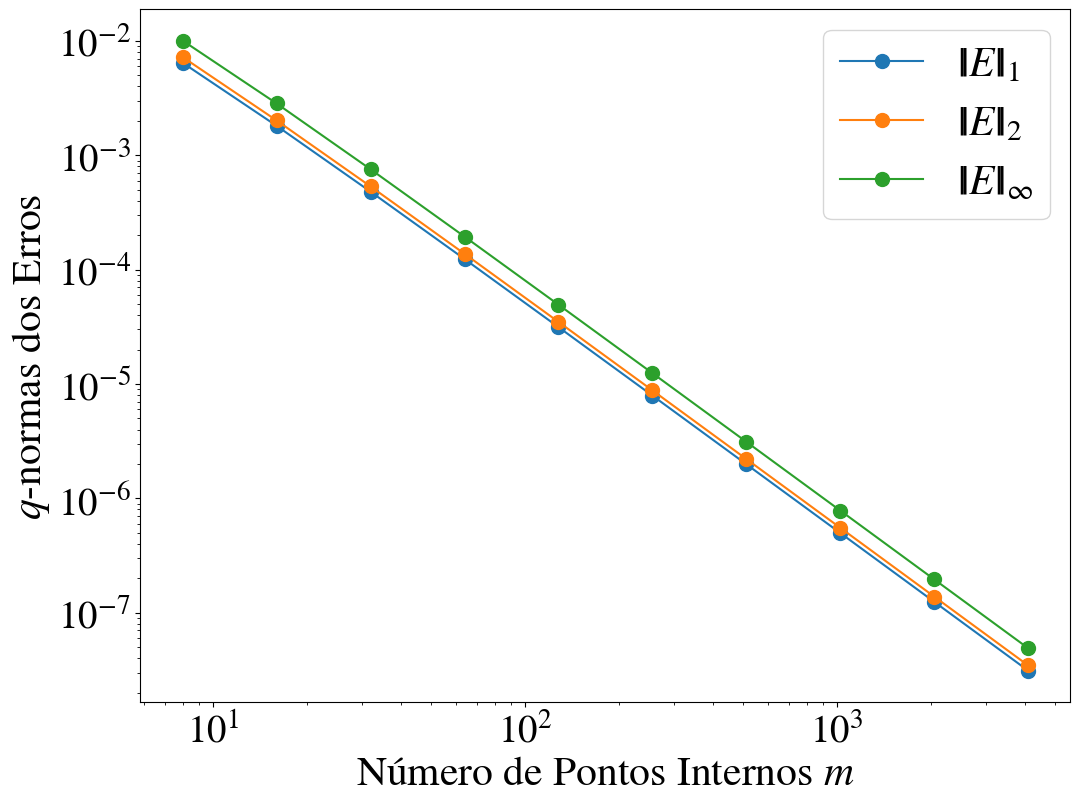

In [4]:
### Plota as normas dos erros em função de m
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'STIXGeneral'

fig, ax = plt.subplots(figsize=(12,9))
ax.loglog(pontos_internos, normas_q[0], 'o-', label=r'$|\!|E|\!|_{1}$', ms=10)
ax.loglog(pontos_internos, normas_q[1], 'o-', label=r'$|\!|E|\!|_{2}$', ms=10)
ax.loglog(pontos_internos, normas_q[2], 'o-', label=r'$|\!|E|\!|_{\infty}$', ms=10)
ax.legend(fontsize=30)


ax.tick_params(axis='both', which='major', labelsize=28)
ax.set_xlabel(r'Número de Pontos Internos $m$', fontsize=30)
ax.set_ylabel(r'$q$-normas dos Erros', fontsize=30)
plt.savefig('normas_erros.svg')
plt.show()